<a href="https://colab.research.google.com/github/lax-17/pose-guided-diffusion-analysis/blob/main/notebooks/Evaluations_on_3epochs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install dependencies
!pip install -q torchmetrics diffusers transformers peft opencv-python-headless

import os, time, torch, gc, cv2, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from diffusers import (
    StableDiffusionPipeline, StableDiffusionAdapterPipeline,
    StableDiffusionControlNetPipeline, ControlNetModel, T2IAdapter, AutoencoderKL
)
from transformers import CLIPTextModel, CLIPTokenizer
from torchmetrics.multimodal.clip_score import CLIPScore
from peft import PeftModel

# 2. Configuration & Constants
PROJECT_ROOT = "/content/drive/MyDrive/pose-guided-diffusion-analysis"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 # Half-precision for faster inference

# Paths for your experiment checkpoints
LORA_PATH = os.path.join(PROJECT_ROOT, "experiments", "baseline_text_only_full", "checkpoint-epoch-3")
ADAPTER_PATH = os.path.join(PROJECT_ROOT, "experiments", "phase3_adapter_pose", "checkpoint-epoch-3")
TEST_DATA = os.path.join(PROJECT_ROOT, "processed_data", "split_test_full.parquet")

def draw_pose(keypoints, h, w):
    """Generates a skeleton map from keypoint coordinates."""
    limbs = [(0,1), (0,2), (1,3), (2,4), (5,6), (5,7), (7,9), (6,8), (8,10), (11,12), (11,13), (13,15), (12,14), (14,16), (5,11), (6,12)]
    colors = [(255,0,0),(255,85,0),(255,170,0),(255,255,0),(170,255,0),(85,255,0),(0,255,0),(0,255,85),(0,255,170),(0,255,255),(0,170,255),(0,85,255),(0,0,255),(85,0,255),(170,0,255),(255,0,255),(255,0,170),(255,0,85)]
    canvas = np.zeros((int(h), int(w), 3), dtype=np.uint8)
    points = np.array(keypoints).reshape(-1, 3)
    for i, (a, b) in enumerate(limbs):
        if a < len(points) and b < len(points) and points[a][2]>0 and points[b][2]>0:
            cv2.line(canvas, (int(points[a][0]), int(points[a][1])), (int(points[b][0]), int(points[b][1])), colors[i%len(colors)], 4)
    for i, (x, y, v) in enumerate(points):
        if v > 0: cv2.circle(canvas, (int(x), int(y)), 4, colors[i%len(colors)], -1)
    return Image.fromarray(canvas)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.2 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
print("Loading Models into GPU Memory...")
MODEL_ID = "runwayml/stable-diffusion-v1-5"

# Shared Components
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=DTYPE).to(DEVICE)
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", torch_dtype=DTYPE).to(DEVICE)
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")

# Scenario A: Baseline Pipeline (LoRA only)
pipe_text = StableDiffusionPipeline.from_pretrained(MODEL_ID, vae=vae, text_encoder=text_encoder, tokenizer=tokenizer, torch_dtype=DTYPE).to(DEVICE)
pipe_text.load_lora_weights(LORA_PATH)
pipe_text.safety_checker = None # Disable filter to prevent black images

# Scenario B: ControlNet Pipeline (The SOTA Benchmark)
cnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-openpose", torch_dtype=DTYPE).to(DEVICE)
pipe_cnet = StableDiffusionControlNetPipeline.from_pretrained(MODEL_ID, controlnet=cnet, vae=vae, text_encoder=text_encoder, tokenizer=tokenizer, torch_dtype=DTYPE).to(DEVICE)
pipe_cnet.load_lora_weights(LORA_PATH)

# Scenario C: T2I-Adapter Pipeline (The Research Focus)
adapter = T2IAdapter.from_pretrained(ADAPTER_PATH, torch_dtype=DTYPE).to(DEVICE)
pipe_ours = StableDiffusionAdapterPipeline.from_pretrained(MODEL_ID, adapter=adapter, vae=vae, text_encoder=text_encoder, tokenizer=tokenizer, torch_dtype=DTYPE).to(DEVICE)
pipe_ours.unet = PeftModel.from_pretrained(pipe_ours.unet, LORA_PATH) # Manual LoRA injection
pipe_ours.safety_checker = None

print("Models initialized successfully.")

⏳ Loading Models into GPU Memory...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Models initialized successfully.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/t2i_adapter/pipeline_stable_diffusion_adapter.py:511: FutureWarning: The decode_latents method is deprecated and will be removed in 1.0.0. Please use VaeImageProcessor.postprocess(...) instead
  deprecate("decode_latents", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

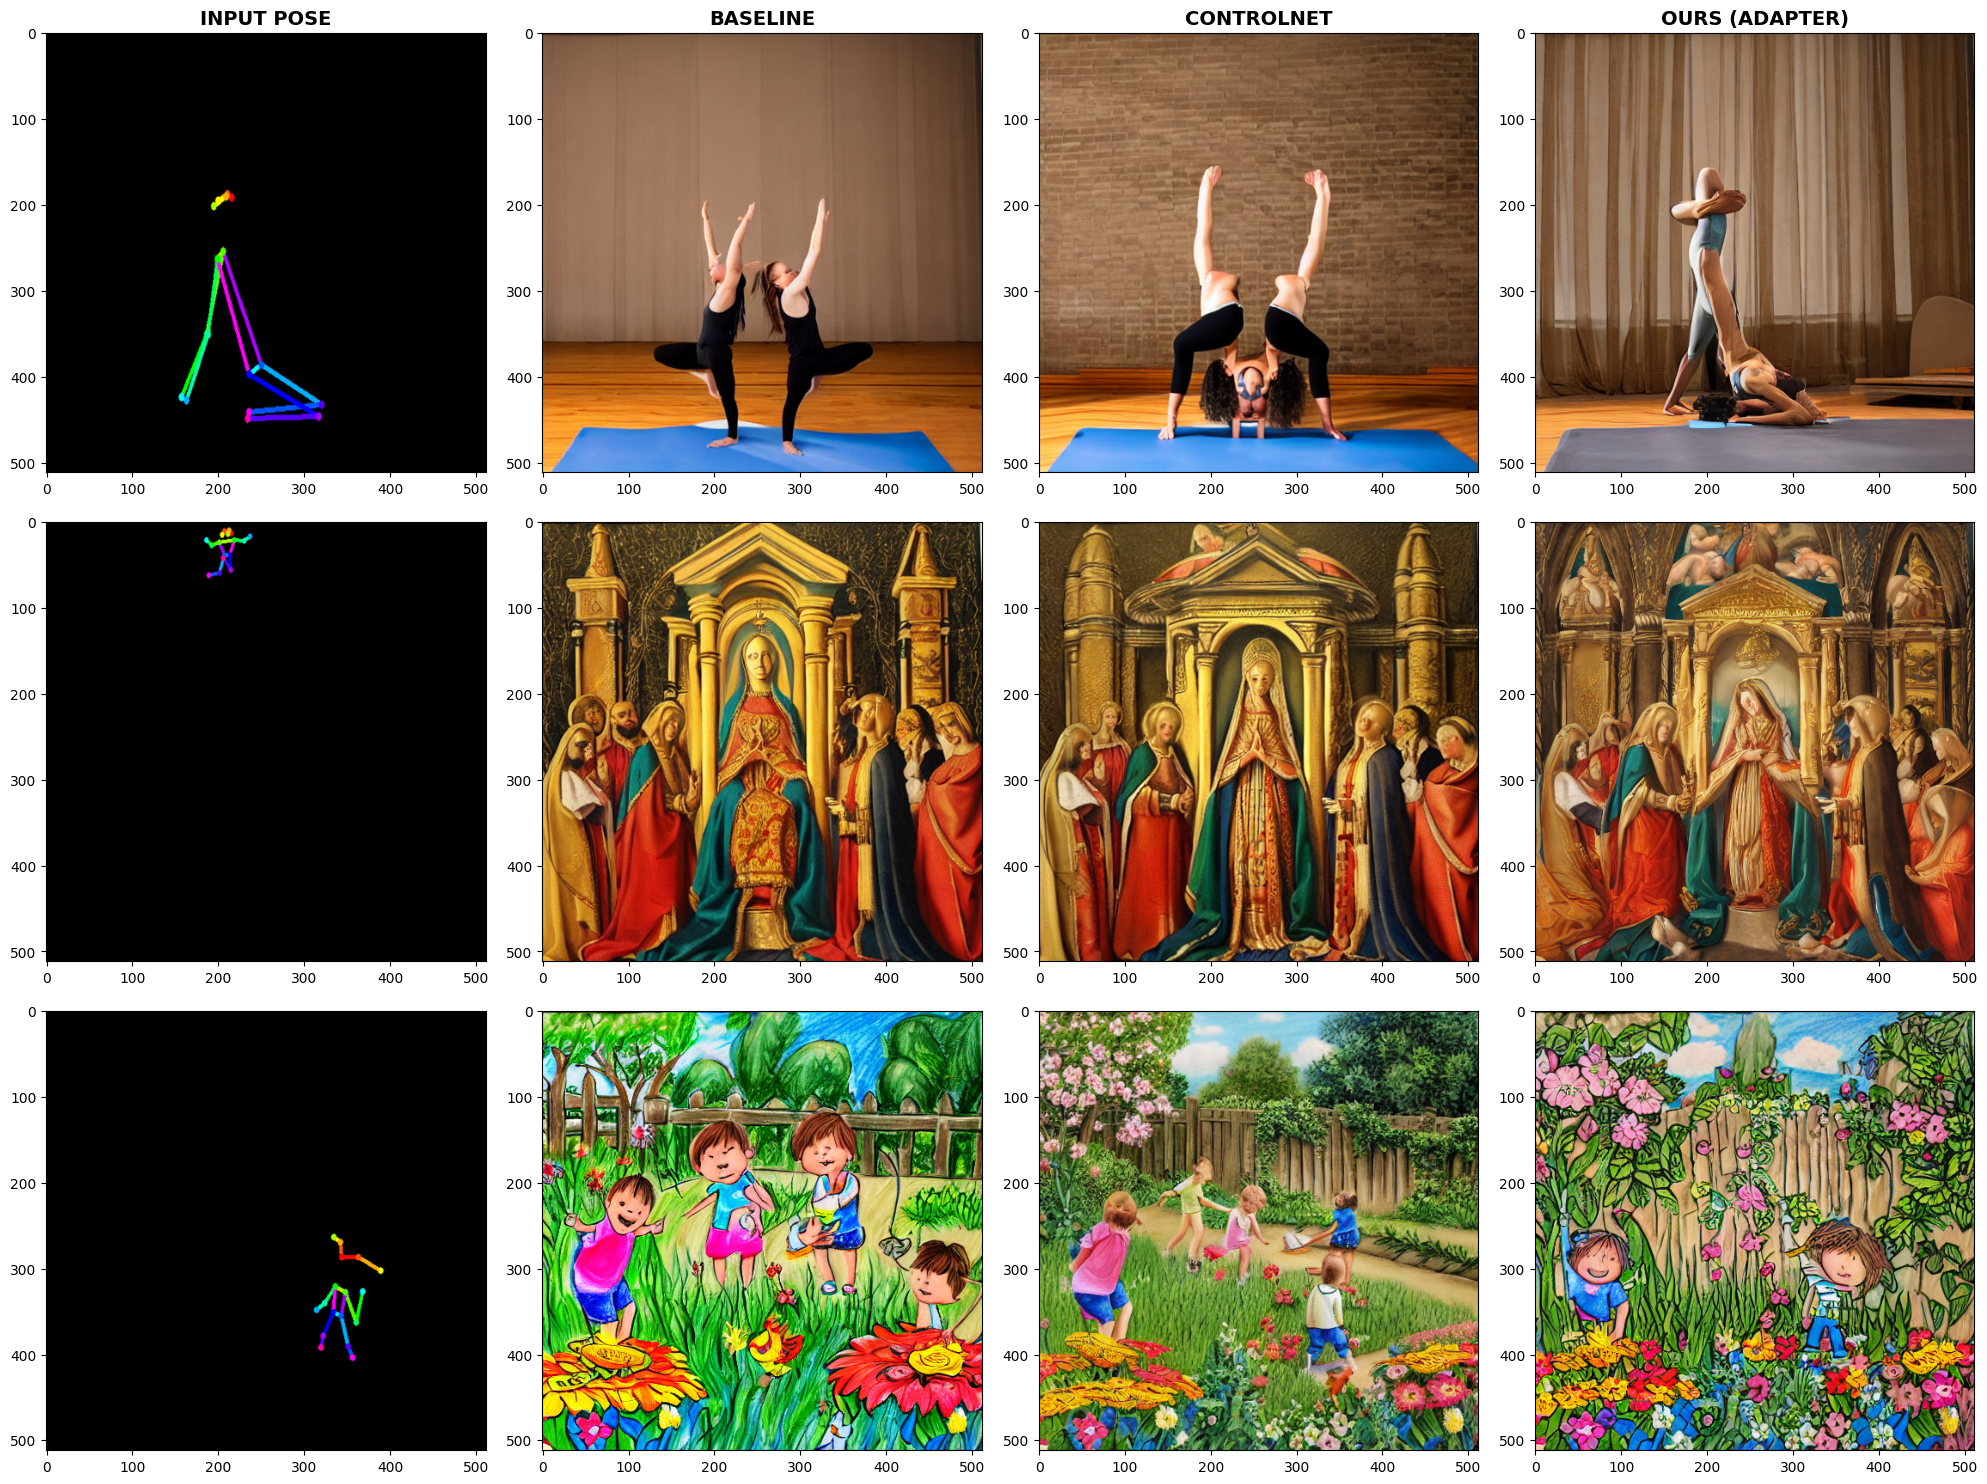

In [4]:
def generate_tableau(num_samples=3):
    df_test = pd.read_parquet(TEST_DATA)
    samples = df_test.sample(num_samples)

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    titles = ["INPUT POSE", "BASELINE", "CONTROLNET", "OURS (ADAPTER)"]

    for i, (idx, row) in enumerate(samples.iterrows()):
        pose = draw_pose(row['keypoints'], row['height'], row['width']).resize((512,512))
        prompt = row['description']

        with torch.inference_mode():
            seed = 42
            g = torch.Generator(DEVICE).manual_seed(seed)
            # Baseline uses prompt only
            img_base = pipe_text(prompt, generator=g).images[0]

            g.manual_seed(seed)
            # ControlNet uses pose at standard scale
            img_cnet = pipe_cnet(prompt, image=pose, controlnet_conditioning_scale=1.0, generator=g).images[0]

            g.manual_seed(seed)
            # Adapter uses high scale (1.5) to force spatial compliance
            img_ours = pipe_ours(prompt, image=pose, adapter_conditioning_scale=1.5, guidance_scale=4.0, generator=g).images[0]

        axes[i,0].imshow(pose); axes[i,1].imshow(img_base); axes[i,2].imshow(img_cnet); axes[i,3].imshow(img_ours)
        if i == 0:
            for j, t in enumerate(titles): axes[i,j].set_title(t, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

generate_tableau(3)